In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
from sklearn.decomposition import TruncatedSVD

Складне зображення:

In [31]:
import matplotlib.cbook as cbook
path = cbook.get_sample_data('grace_hopper.jpg', asfileobj=False)
img_complex = imread(path)

Просте зображення:

In [48]:
# Fallback: synthetic simple image (geometric)
# Create a white canvas + black shapes
H, W = 256, 256
simple = np.ones((H, W, 3), dtype=np.uint8) * 255

# Draw a black rectangle
simple[60:120, 40:220] = 0

# Draw a circle-like blob (approx)
yy, xx = np.ogrid[:H, :W]
mask = (yy - 180)**2 + (xx - 128)**2 <= 35**2
simple[mask] = 0

img_simple = simple
#print("Synthetic simple shape:", img_simple.shape, img_simple.dtype)
#show_image(img_simple, "Simple image (synthetic)")

In [36]:
# Перетворити у 2D для SVD
def image_to_flat2d(image):
    # Якщо RGB (3D)
    if image.ndim == 3:
        height, width, channels = image.shape

        # якщо float [0,1] — переведемо в [0,255] для зрозумілої інтерпретації
        if image.dtype != np.uint8:
            image_255 = (image * 255).astype(np.float64)
        else:
            image_255 = image.astype(np.float64)

        flat_image = image_255.reshape(height, width * channels)
    # Якщо grayscale (2D)
    else:
        height, width = image.shape
        channels = 1

        if image.dtype != np.uint8:
            image_255 = (image * 255).astype(np.float64)
        else:
            image_255 = image.astype(np.float64)

        flat_image = image_255  # already 2D

    return flat_image, (height, width, channels), image_255

In [37]:
# реконстуйоване зображення
def flat2d_to_image(rec2d, meta):
    height, width, channels = meta
    if channels == 1:
        rec = rec2d.reshape(height, width)
    else:
        rec = rec2d.reshape(height, width, channels)
    rec = np.clip(rec, 0, 255).astype('uint8')
    return rec

In [57]:
def plot_sigma_downscaled(flat2d, title="", max_h=200, max_w=300, top_k=200):
  #Plot singular values (Sigma) using downscaled full SVD.
  # downscale, щоб не "вбити" ноутбук
  h, w = flat2d.shape
  step_h = max(1, h // max_h)
  step_w = max(1, w // max_w)
  small = flat2d[::step_h, ::step_w]

  U, S, Vt = np.linalg.svd(small, full_matrices=False)

  k = min(top_k, len(S))
  plt.figure(figsize=(7,4))
  plt.plot(np.arange(k), S[:k])
  plt.title(f"Singular values (Sigma) — {title}\n(on downscaled matrix {small.shape})")
  plt.xlabel("index")
  plt.ylabel("singular value")
  plt.grid(True)
  plt.show()

  return S

In [54]:
def compress_reconstruct(flat_image, k, random_state=42):
    k_eff = int(min(k, min(flat_image.shape) - 1)) # щоб не було помилок
    svd = TruncatedSVD(n_components=k, random_state=random_state)
    # скорочення зображення
    transformed = svd.fit_transform(flat_image)
    # реконструйоване зображення
    reconstructed = svd.inverse_transform(transformed)
    # помилка реконструкції
    mse = np.mean((reconstructed - flat_image) ** 2)
    evr = float(np.sum(svd.explained_variance_ratio_))  # total explained variance ratio (approx)
    return k_eff, reconstructed, mse, evr

In [63]:
def show_image(img, title="", figsize=(5,5)):
    plt.figure(figsize=figsize)
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()


def describe_image_inputs(image, name):
    """Print basic info + show original image."""
    flat2d, meta, img255 = image_to_flat2d(image)

    print(f"\n=== {name} ===")
    print("Original shape:", image.shape, "dtype:", image.dtype)
    print("Flat2D shape:", flat2d.shape, "meta:", meta)
    print("Range [min,max]:", float(img255.min()), float(img255.max()))

    # show original
    show_image(img255.astype("uint8"), f"{name} — original", figsize=(5, 5))
    return flat2d, meta, img255


def evaluate_k_list(flat2d, meta, k_list, name):
    """
    For each k:
      - compress + reconstruct (2D)
      - compute mse, evr
      - convert to image for visualization
    Returns:
      - df_res (k,mse,explained_var)
      - rec_images list of tuples (k_eff, rec_img, mse, evr)
    """
    rows = []
    rec_images = []

    for k in k_list:
        k_eff, rec2d, mse, evr = compress_reconstruct(flat2d, k)
        rows.append({"image": name, "k": k_eff, "mse": mse, "explained_var": evr})

        rec_img = flat2d_to_image(rec2d, meta)
        rec_images.append((k_eff, rec_img, mse, evr))

    df_res = (
        pd.DataFrame(rows)
        .drop_duplicates(subset=["image", "k"])
        .sort_values("k")
        .reset_index(drop=True)
    )
    return df_res, rec_images


def plot_mse_vs_k(df_res, name):
    """Plot MSE(k)."""
    plt.figure(figsize=(7, 4))
    plt.plot(df_res["k"], df_res["mse"], marker="o")
    plt.title(f"MSE vs k — {name}")
    plt.xlabel("k (n_components)")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.show()


def plot_explained_variance_vs_k(df_res, name):
    """Plot sum explained_variance_ratio_ (approx) vs k."""
    plt.figure(figsize=(7, 4))
    plt.plot(df_res["k"], df_res["explained_var"], marker="o")
    plt.title(f"Explained variance ratio (sum) vs k — {name}")
    plt.xlabel("k (n_components)")
    plt.ylabel("sum explained_variance_ratio_")
    plt.grid(True)
    plt.show()


def plot_reconstructions_grid(img255, rec_images, name, cols=4):
    """
    Show original + reconstructions in a grid.
    rec_images: list (k_eff, rec_img, mse, evr)
    """
    n = len(rec_images) + 1  # +1 for original
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(4 * cols, 4 * rows))

    # original
    plt.subplot(rows, cols, 1)
    plt.imshow(img255.astype("uint8"), cmap=("gray" if img255.ndim == 2 else None))
    plt.axis("off")
    plt.title(f"{name}\nOriginal")

    # reconstructions
    for i, (k_eff, rec_img, mse, evr) in enumerate(rec_images, start=2):
        plt.subplot(rows, cols, i)
        plt.imshow(rec_img, cmap=("gray" if rec_img.ndim == 2 else None))
        plt.axis("off")
        #plt.title(f"k={k_eff}\nMSE={mse:.1f}\nEVR={evr:.2f}")
        plt.title(f"k={k_eff}\nMSE={mse:.1f}")

    plt.tight_layout()
    plt.show()


Експерименти з різними k та помилка реконструкції зображення


=== Complex image ===
Original shape: (600, 512, 3) dtype: uint8
Flat2D shape: (600, 1536) meta: (600, 512, 3)
Range [min,max]: 0.0 255.0


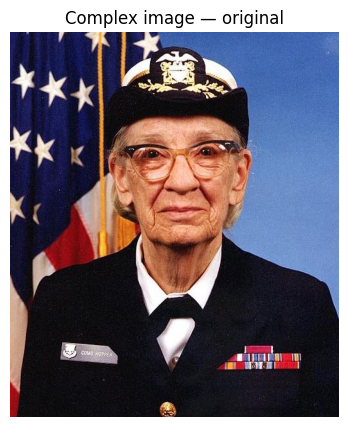

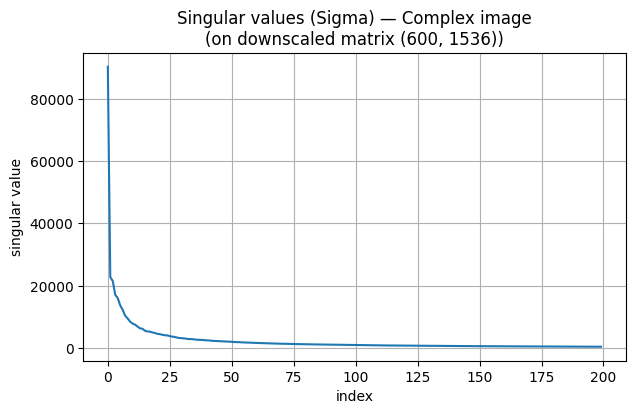

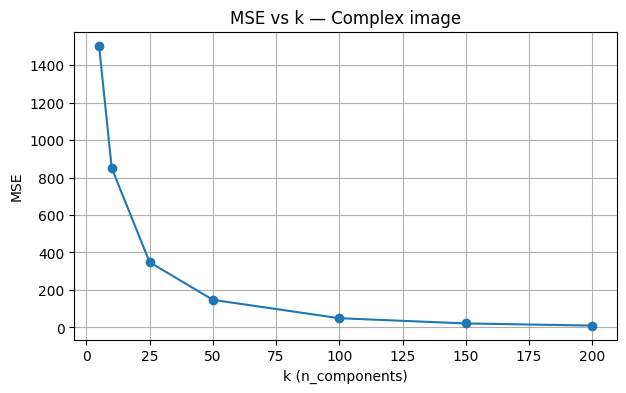

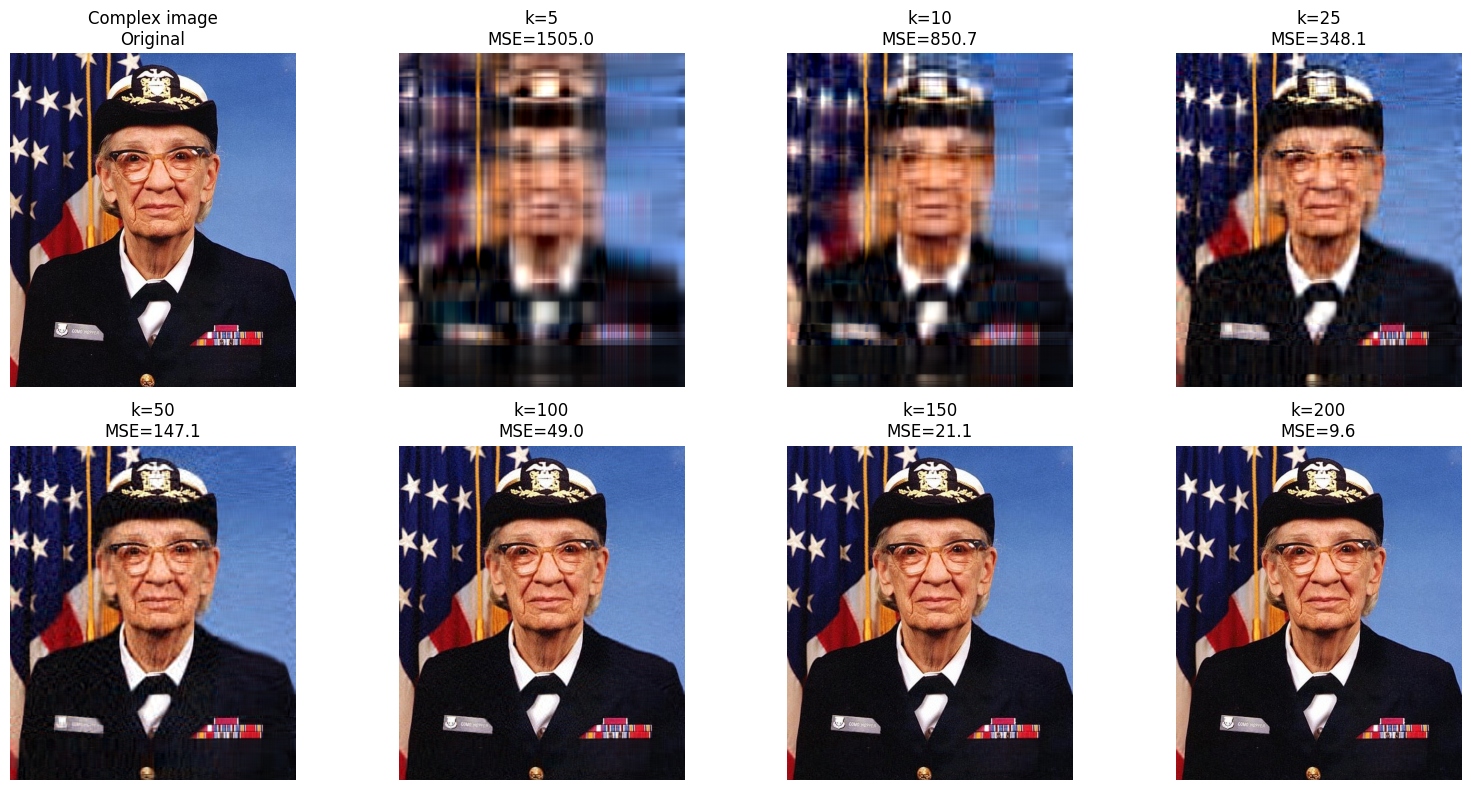


=== Simple image ===
Original shape: (256, 256, 3) dtype: uint8
Flat2D shape: (256, 768) meta: (256, 256, 3)
Range [min,max]: 0.0 255.0


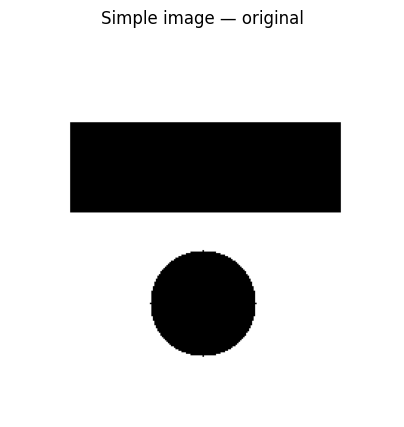

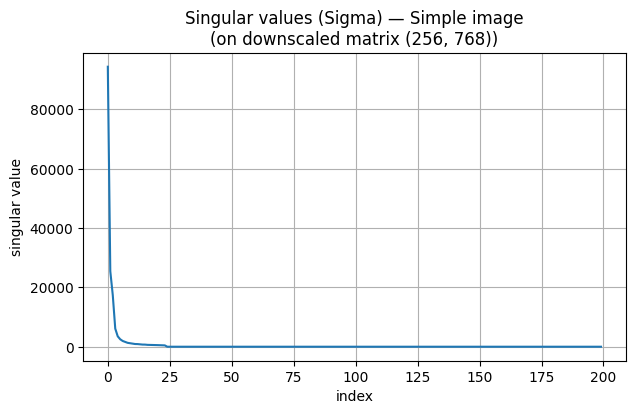

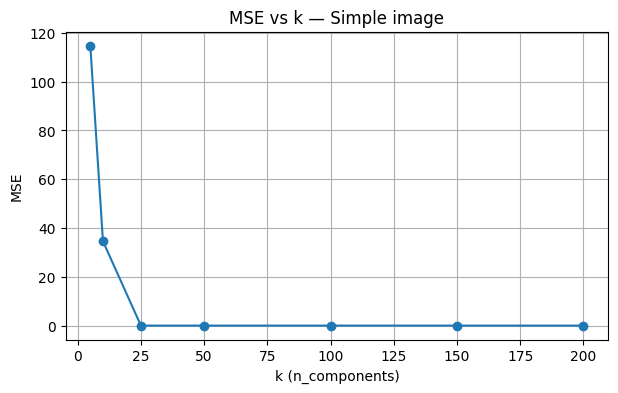

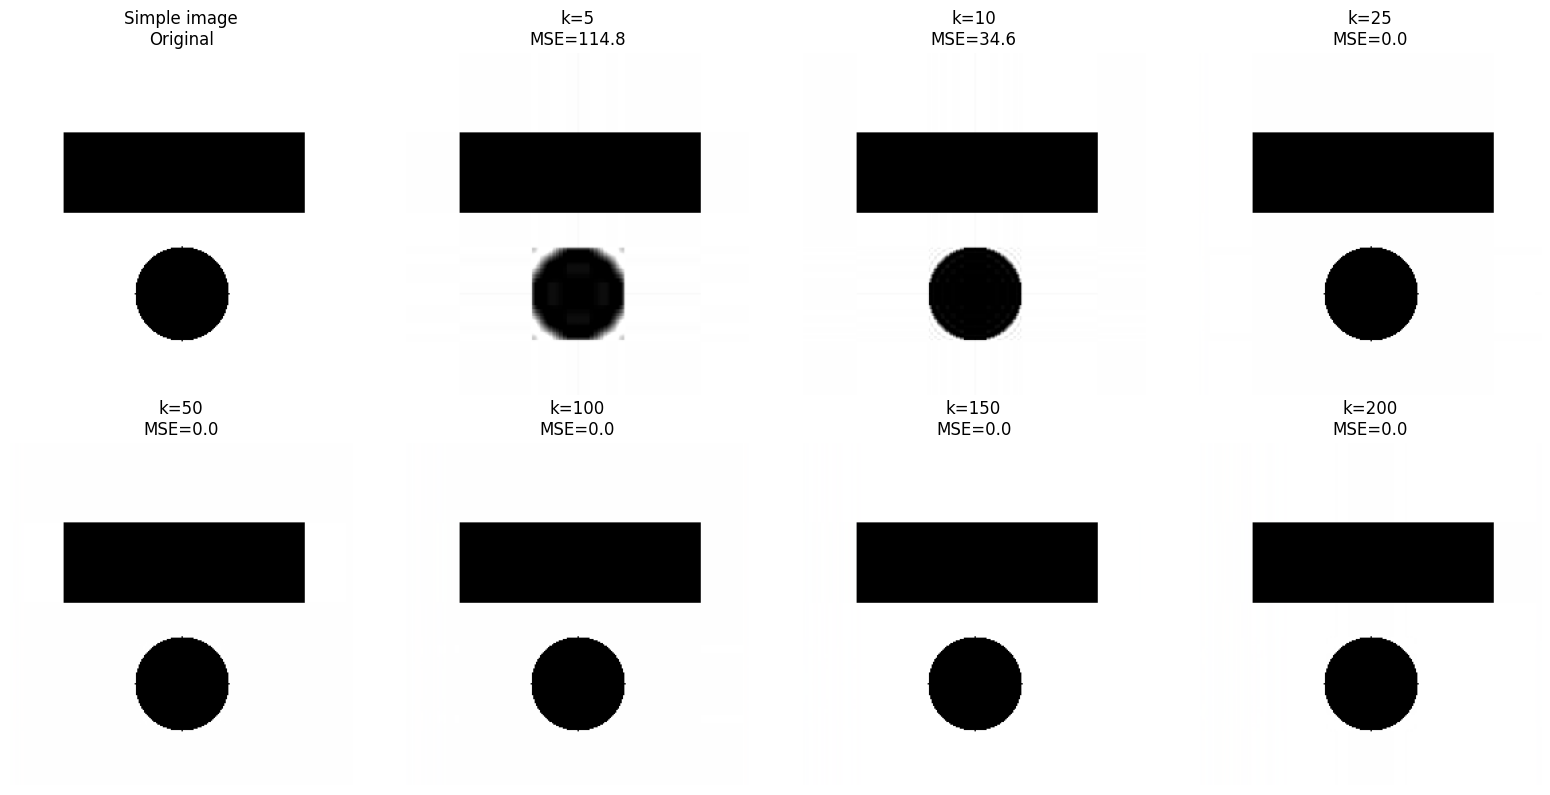

In [66]:
def run_experiment(image, name, k_list, show_sigma=True):
    """
    High-level pipeline for one image:
      1) describe + show original
      2) optional sigma plot
      3) run k sweep (TruncatedSVD)
      4) plot metrics
      5) show reconstructions
    Returns:
      df_res (metrics per k)
    """
    flat2d, meta, img255 = describe_image_inputs(image, name)

    if show_sigma:
        plot_sigma_downscaled(flat2d, name)

    df_res, rec_images = evaluate_k_list(flat2d, meta, k_list, name)

    plot_mse_vs_k(df_res, name)
    #plot_explained_variance_vs_k(df_res, name) - не передбачено вимогами
    plot_reconstructions_grid(img255, rec_images, name)

    return df_res

k_list = [5, 10, 25, 50, 100, 150, 200]

df_complex = run_experiment(img_complex, "Complex image", k_list)
df_simple  = run_experiment(img_simple,  "Simple image",  k_list)

1) Загальна постановка

У роботі було проведено порівняння SVD-компресії для двох типів зображень:

- Складне фото (містить текстури, градієнти, дрібні деталі)

- Просте зображення (логотип/геометрична фігура з великими однорідними областями)

Аналіз виконано за допомогою:

- графіка сингулярних значень (матриця Σ),

- залежності MSE від k,

- візуальної оцінки реконструкцій.

2. Порівняння швидкості спадання MSE

Для простого зображення:

- різке зменшення MSE спостерігається вже при k ≈ 10

- прийнятна якість досягається при k ≈ 25

Для складного фото:

- різке зменшення MSE відбувається повільніше

- прийнятна якість досягається лише при k ≈ 50

Таким чином, просте зображення потребує значно меншої кількості компонент для якісної реконструкції.

3. Аналіз сингулярних значень (Σ)

Для простого зображення:

- перші кілька сингулярних значень значно перевищують інші

- спостерігається швидке спадання спектру

Для складного фото:

- спадання сингулярних значень є більш поступовим

- енергія розподілена між більшою кількістю компонент

Це свідчить про різну структурну складність зображень.

**Ключовий висновок:**

Ефективність SVD-компресії безпосередньо залежить від структурної складності зображення.

Для простих структур із низьким ефективним рангом прийнятна якість досягається при малих k.

Для складних зображень із великою кількістю деталей потрібно значно більше компонент.

Це демонструє фундаментальний принцип задач зменшення розмірності:
чим складніша структура даних, тим більший ранг необхідний для точного наближення.

Для простого зображення більшість енергії (інформації) зосереджена в перших сингулярних значеннях, тому вже при малому k досягається якісна реконструкція.

Для складного фото сингулярні значення спадають повільніше, що означає розподіл інформації між багатьма компонентами. Тому для збереження деталей необхідне більше значення k.